# Agent-based Simulation with MESA
Mesa allows users to quickly create agent-based models using built-in core components (such as spatial grids and agent schedulers) or customized implementations; visualize them using a browser-based interface; and analyze their results using Python’s data analysis tools.

## Set up
[Installation guide](https://mesa.readthedocs.io/latest/index.html) on its official website.  
Use Conda(https://anaconda.org/conda-forge/mesa) to install for manageability in controlled environment.

In [12]:
!python -V

Python 3.13.2


In [7]:
%%capture
conda install conda-forge::mesa

In [8]:
conda list mesa

# packages in environment at /opt/miniconda3/envs/my_env:
#
# Name                    Version                   Build  Channel
mesa                      3.2.0              pyhd8ed1ab_0    conda-forge

Note: you may need to restart the kernel to use updated packages.


### Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import mesa

## Create Agent
Follow the [tutorial](https://mesa.readthedocs.io/latest/tutorials/0_first_model.html) from Mesa document.  
This particular case simulate an economy with agents as consumer or producer exanging money. [[Drăgulescu, 2002](https://arxiv.org/abs/cond-mat/0211175)]. 

An agent has a initial state and actions defined with functions.  
`exchange`: the agent will check its wealth, and if it has money, give one unit of it away to another random agent.

In [23]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # Pass the parameters to the parent class.
        super().__init__(model)
        # Create the agent's variable and set the initial values.
        self.wealth = 1

    def say_hi(self):
        # The agent's step will go here.
        # For demonstration purposes we will print the agent's unique_id
        print(f"Hi, I am an agent, you can call me {self.unique_id!s}.")
        
    def say_wealth(self):
        print(f"my wealth is {self.wealth}")

    def exchange(self):
        # Verify agent has some wealth
        if self.wealth > 0:
            other_agent = self.random.choice(self.model.agents)
            if other_agent is not None:
                other_agent.wealth += 1
                self.wealth -= 1

## Create Model
A model is a set of agents.  
Use `step` function to tell agent what to do in one smallest unit of time(tick/step) in the model.

In [24]:
class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n, seed=None):
        super().__init__(seed=seed)
        self.num_agents = n
        # Create agents
        MoneyAgent.create_agents(model=self, n=n)
        
    def step(self):
        """Advance the model by one step."""
        # This function psuedo-randomly reorders the list of agent objects and
        # then iterates through calling the function passed in as the parameter
        
        # self.agents.shuffle_do("say_hi")
        self.agents.shuffle_do("exchange")

## Running the Model

### Instantiate our pre-defined model and call the step method(in each step, randomly choose one agent and call `say_hi` function) one time.

In [20]:
starter_model = MoneyModel(10, seed=42)
starter_model.step()

Hi, I am an agent, you can call me 8.
Hi, I am an agent, you can call me 4.
Hi, I am an agent, you can call me 3.
Hi, I am an agent, you can call me 9.
Hi, I am an agent, you can call me 6.
Hi, I am an agent, you can call me 7.
Hi, I am an agent, you can call me 10.
Hi, I am an agent, you can call me 5.
Hi, I am an agent, you can call me 1.
Hi, I am an agent, you can call me 2.


### Create 10 agents and run 30 steps, each steps randomly choose one agent to call `exchange` function.

In [29]:
model = MoneyModel(10, seed=42)  # Tells the model to create 10 agents
for _ in range(30):  # Runs the model for 30 steps;
    model.step()
# Note: An underscore is common convention for a variable that is not used.

### Visulize the distribution of wealth among agents.

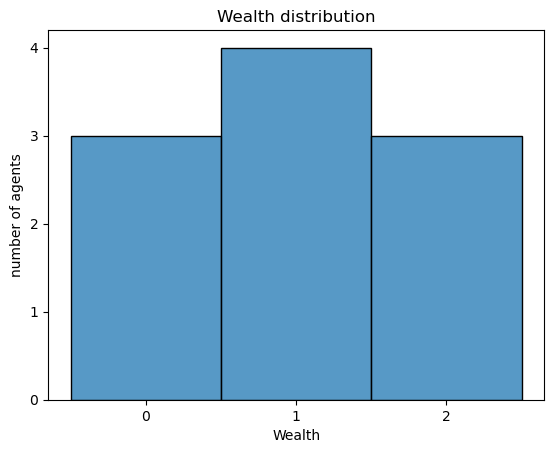

In [33]:
import matplotlib.ticker as ticker

agent_wealth = [a.wealth for a in model.agents]
# Create a histogram with seaborn
g = sns.histplot(agent_wealth, discrete=True)
g.set(
    title="Wealth distribution", xlabel="Wealth", ylabel="number of agents"
);  # The semicolon is just to avoid printing the object representation
g.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
g.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

### Run 100 agents for 30 steps.

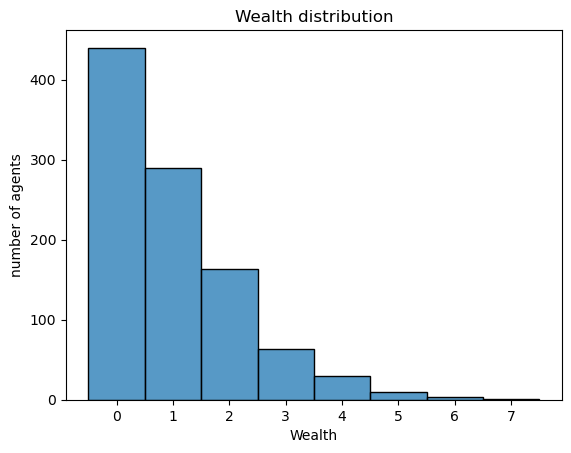

In [35]:
all_wealth = []
# This runs the model 100 times, each model executing 30 steps.
for _ in range(100):
    # Run the model
    model = MoneyModel(10)
    for _ in range(30):
        model.step()

    # Store the results
    for agent in model.agents:
        all_wealth.append(agent.wealth)

# Use seaborn
g = sns.histplot(all_wealth, discrete=True)
g.set(title="Wealth distribution", xlabel="Wealth", ylabel="number of agents");

## Adding Space
Display agents on a 2D grid.  
Use `CellAgent` subclass to handle interaction on grid.  
During each step, each agent will randomly move to one of its moore neighborhood and exchange money with random agent in its moore neighborhood like the first model.  
- `Network` in grid space seems interesting.
- [Mesa-Geo](https://mesa-geo.readthedocs.io/latest/): Extension of Mesa with geographic information.

In [4]:
# Import Cell Agent and OrthogonalMooreGrid
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid


# Instantiate MoneyAgent as CellAgent
class MoneyAgent(CellAgent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, cell):
        super().__init__(model)
        self.cell = cell  # Instantiate agent with location (x,y)
        self.wealth = 1

    # Move Function
    def move(self):
        self.cell = self.cell.neighborhood.select_random_cell()

    def give_money(self):
        cellmates = [
            a for a in self.cell.agents if a is not self
        ]  # Get all agents in cell

        if self.wealth > 0 and cellmates:
            other_agent = self.random.choice(cellmates)
            other_agent.wealth += 1
            self.wealth -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n, width, height, seed=None):
        super().__init__(seed=seed)
        self.num_agents = n
        # Instantiate an instance of Moore neighborhood space
        self.grid = OrthogonalMooreGrid(
            (width, height), torus=True, capacity=10, random=self.random
        )

        # Instantiate DataCollector
        self.datacollector = mesa.DataCollector(
            model_reporters={"Gini": compute_gini}, agent_reporters={"Wealth": "wealth"}
        )

        # Create agents
        agents = MoneyAgent.create_agents(
            self,
            self.num_agents,
            # Randomly select agents cell
            self.random.choices(self.grid.all_cells.cells, k=self.num_agents),
        )

    def step(self):
        # Collect data each step
        self.datacollector.collect(self)
        self.agents.shuffle_do("move")
        self.agents.do("give_money")

### Create a model with 100 agents on a 10x10 grid, and run it for 20 steps.

In [5]:
model = MoneyModel(100, 10, 10)
for _ in range(20):
    model.step()

### Visulization of agents' position on grid

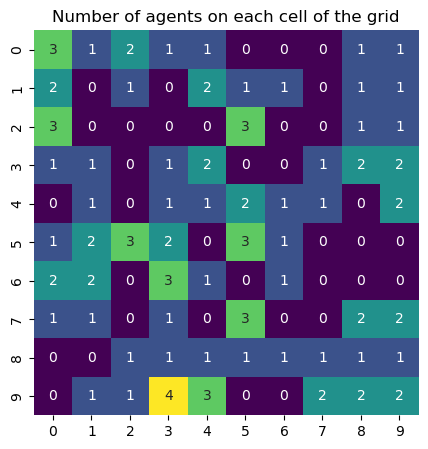

In [42]:
agent_counts = np.zeros((model.grid.width, model.grid.height))

for cell in model.grid.all_cells:
    agent_counts[cell.coordinate] = len(cell.agents)
# Plot using seaborn, with a visual size of 5x5
g = sns.heatmap(agent_counts, cmap="viridis", annot=True, cbar=False, square=True)
g.figure.set_size_inches(5, 5)
g.set(title="Number of agents on each cell of the grid");

### Visulization of wealth distribution

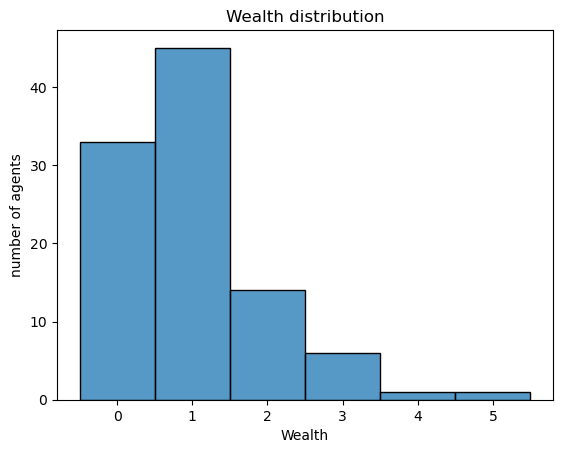

In [43]:
agent_wealth = [a.wealth for a in model.agents]
# Create a histogram with seaborn
g = sns.histplot(agent_wealth, discrete=True)
g.set(
    title="Wealth distribution", xlabel="Wealth", ylabel="number of agents"
);  # The semicolon is just to avoid printing the object representation

## Collecting Data
Add `mesa.Datacollector` in the model definition(in Adding Space section).
- At the model level, measure the model’s [Gini Coefficient](https://en.wikipedia.org/wiki/Gini_coefficient), a measure of wealth inequality.
- At the agent level, collect every agent’s wealth at every step.

In [3]:
# Add function for model level collection
def compute_gini(model):
    agent_wealths = [agent.wealth for agent in model.agents]
    x = sorted(agent_wealths)
    n = model.num_agents
    B = sum(xi * (n - i) for i, xi in enumerate(x)) / (n * sum(x))
    return 1 + (1 / n) - 2 * B

### Extract MoneyModel data in a Pandas dataframe step-wise

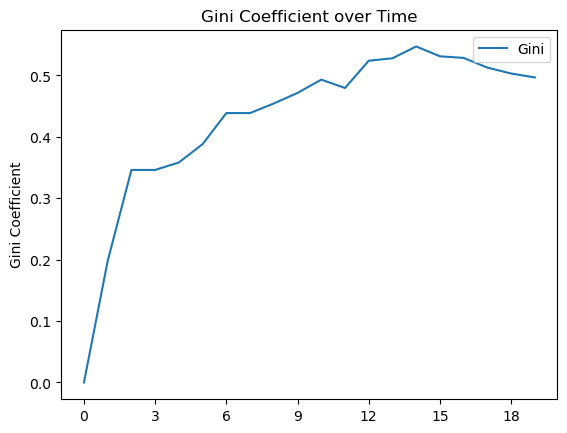

In [8]:
import matplotlib.ticker as ticker
# Extract MoneyModel data in a Pandas dataframe
gini = model.datacollector.get_model_vars_dataframe()

g = sns.lineplot(data=gini)
g.set(title="Gini Coefficient over Time", ylabel="Gini Coefficient");
g.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

Data collector stores the data in a dictionary, with the step number as the key, and a dictionary of agent ID and variable value pairs as the value. The data collector then converts this dictionary into a DataFrame, which is why the index is a pair of (model step, agent ID).

In [9]:
# Extract MoneyAgent data in a Pandas dataframe
agent_wealth = model.datacollector.get_agent_vars_dataframe()
agent_wealth.head()

Wealth
Step AgentID        
1    1             1
     2             1
     3             1
     4             1
     5             1